# Traitement d'images: 
## en analyse non supervisée
## en analyse semi-supervisée

In [46]:
# === Data manipulation ===
import numpy as np
import pandas as pd

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# === Machine Learning===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, adjusted_rand_score, f1_score, precision_recall_curve,confusion_matrix,roc_curve, average_precision_score, classification_report, auc
from sklearn.metrics import f1_score as sklearn_f1
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

# === Computer Vision ===
import cv2


# === Deep Learning (TensorFlow / Keras) ===
import tensorflow as tf
keras = tf.keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.metrics import AUC, Precision, Recall, FalsePositives, FalseNegatives


import os
import random
import hashlib
from collections import defaultdict

print ("imports terminés")


imports terminés


## Analyse Exploratoire des données

In [2]:
print(os.listdir(r"data\mri_dataset_brain_cancer_oc"))

['avec_labels', "Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt", 'sans_label']


exploration visuelle

cv2, module Python de la bibliotheque OpenCV pour le traitement d'images

recheche d'images illisibles et verification des dimensions de tout le data set

In [3]:
dataset_path = "data/mri_dataset_brain_cancer_oc"
valid_ext = (".jpg", ".jpeg", ".png")

sizes = []
bad_images = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if not file.lower().endswith(valid_ext):
            continue

        img_path = os.path.join(root, file)

        img = cv2.imread(img_path)

        if img is None:
            bad_images.append(img_path)
            print("Image illisible :", img_path)
            continue

        sizes.append(img.shape)

print("\nNombre d'images illisibles :", len(bad_images))
print("Tailles uniques des images :", set(sizes))


Nombre d'images illisibles : 0
Tailles uniques des images : {(512, 512, 3)}


Vérification des doublons (par hashing, avec chunks pour economiser de la memoire)

hashing en sha256

In [4]:
dataset_path = r"data/mri_dataset_brain_cancer_oc"
valid_ext = (".png", ".jpg", ".jpeg")

hash_dict = defaultdict(list)

def get_hash(filepath):
    hasher = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if not file.lower().endswith(valid_ext):
            continue

        path = os.path.join(root, file)

        file_hash = get_hash(path)

        hash_dict[file_hash].append(path)


duplicates = {h: p for h, p in hash_dict.items() if len(p) > 1}

print("Nombre de groupes de doublons :", len(duplicates))

Nombre de groupes de doublons : 90


recherche du chemin des doublons concernés

In [5]:
for h, paths in duplicates.items():
    print("\nDoublon détecté :")
    for p in paths:
        print(p)


Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\11a7a426-4806-401e-98b2-b96e7094d1a6.jpg
data/mri_dataset_brain_cancer_oc\sans_label\f9466180-1e6b-4152-9176-6b4e2dc186ed.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\5af7f2cb-a82b-4635-865e-5b57dbc7a087.jpg
data/mri_dataset_brain_cancer_oc\sans_label\bd90cca9-a572-4464-b6fd-edb2af3e9a15.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\7e3f6acd-c9cc-440e-ba01-fedab0462fed.jpg
data/mri_dataset_brain_cancer_oc\sans_label\e9721e3a-e3c6-4a09-9b30-3c82b809069e.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\9ff6e310-b23a-4240-ac18-9fd99bd48e80.jpg
data/mri_dataset_brain_cancer_oc\sans_label\74486ecc-2beb-460d-89cb-50880e1a3daa.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\a8319ab8-471b-4d18-bb47-a377c4f9bd38.jpg
data/mri_dataset_brain_cancer_oc\sans_label\cf0cf298-45f4-4e43-a388-5a0d5f4b6095.jpg

Doublon détect

vérification visuelle des doublons (sur 3 groupes)

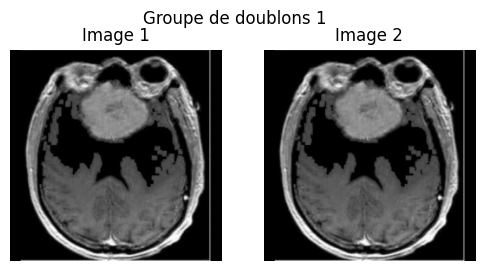

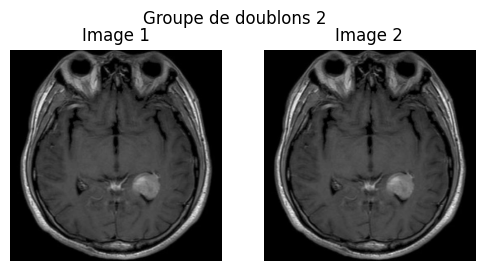

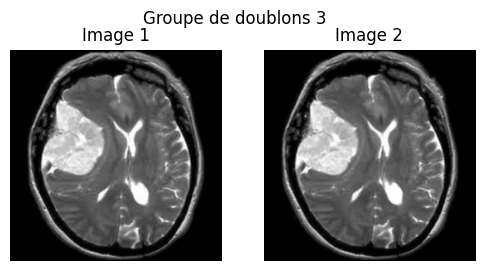

In [6]:
sample_duplicates = list(duplicates.items())[:3]

for i, (h, paths) in enumerate(sample_duplicates):

    n = len(paths)

    plt.figure(figsize=(3*n, 3))

    for j, path in enumerate(paths):

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, j+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {j+1}")

    plt.suptitle(f"Groupe de doublons {i+1}")
    plt.show()

=>les images identiques prouvent l'existence de doublons

Suppression des doublons: 3 cas possibles:

1_Si un doublon existe entre avec_labels et sans_label: on garde l'image avec_label;

2_Si les doublons sont dans le même dossier (avec_labels): on garde la première image;

3_Si les doublons sont dans le même dossier (sans_label): on garde la première image.

In [7]:
deleted = 0

for paths in duplicates.values():

    labeled = [p for p in paths if "avec_labels" in p]
    unlabeled = [p for p in paths if "sans_label" in p]

    # CAS 1 : doublon entre labeled et unlabeled
    if len(labeled) > 0 and len(unlabeled) > 0:

        # garder la première image avec label
        keep = labeled[0]

        # supprimer toutes les unlabeled
        for p in unlabeled:
            os.remove(p)
            deleted += 1
            print("Supprimé (sans label doublon) :", p)

        # si plusieurs labeled, garder la première
        for p in labeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon labeled) :", p)

    # CAS 2 : uniquement labeled
    elif len(labeled) > 0:

        keep = labeled[0]

        for p in labeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon labeled) :", p)

    # CAS 3 : uniquement unlabeled
    else:

        keep = unlabeled[0]

        for p in unlabeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon unlabeled) :", p)

print("Total supprimé :", deleted)

Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\f9466180-1e6b-4152-9176-6b4e2dc186ed.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\bd90cca9-a572-4464-b6fd-edb2af3e9a15.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\e9721e3a-e3c6-4a09-9b30-3c82b809069e.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\74486ecc-2beb-460d-89cb-50880e1a3daa.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\cf0cf298-45f4-4e43-a388-5a0d5f4b6095.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\6e0979a9-aef4-4745-bc30-8a507398da26.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\3d09671b-9479-4ec9-a9cf-2934ad88657b.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\647895dc-e736-4a30-bc1b-71c5b3065b17.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc

détection d’outliers (images très sombres-intensité à 0, ou toutes blanches-intensité à 255, totalement illisibles)

In [8]:
means = []

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):

            img = cv2.imread(os.path.join(class_path, img_name))

            if img is not None:
                means.append(img.mean())

print("\nStatistiques intensité pixels :")
print("Min :", np.min(means))
print("Max :", np.max(means))
print("Mean :", np.mean(means))


Statistiques intensité pixels :
Min : 14.945938110351562
Max : 136.21646881103516
Mean : 51.60526270688171


Histogramme des intensités (détection d’outliers)

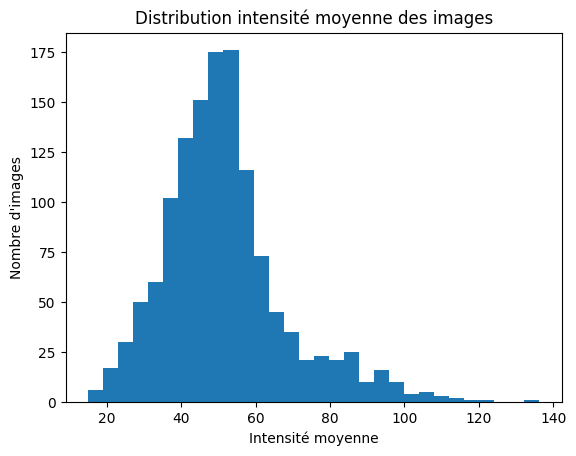

In [9]:
plt.hist(means, bins=30)
plt.title("Distribution intensité moyenne des images")
plt.xlabel("Intensité moyenne")
plt.ylabel("Nombre d'images")
plt.show()

=>on conserve toutes les images: pas d'images noires (0) ni blanches (255)

on fera une normalisation plus tard sur les images pour diminuer l'intensité

Explorer les données labelisées (distribution des classes)

In [2]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"

for cls in os.listdir(base_path):  
    class_path = os.path.join(base_path, cls)
    if os.path.isdir(class_path):
        print(cls, ":", len(os.listdir(class_path)), "images")

cancer : 50 images
normal : 49 images


tailles des images sur **données labelisées**

In [3]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
valid_extensions = (".jpg", ".jpeg", ".png")

sizes = []

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    for img_name in images[:]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        sizes.append(img.shape)

print("Tailles uniques trouvées :", set(sizes))

Tailles uniques trouvées : {(512, 512, 3)}


Affichage de quelques images labelisées par classe 

les pixels utilisent 3 canaux de couleur RGB

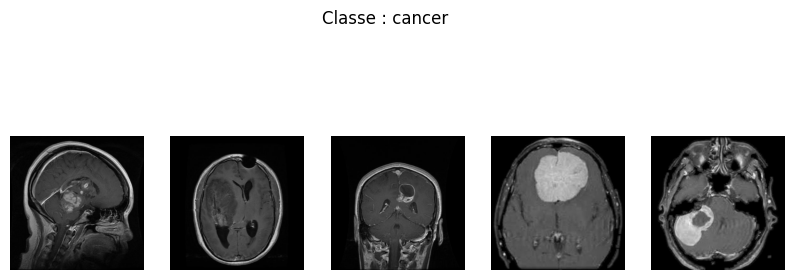

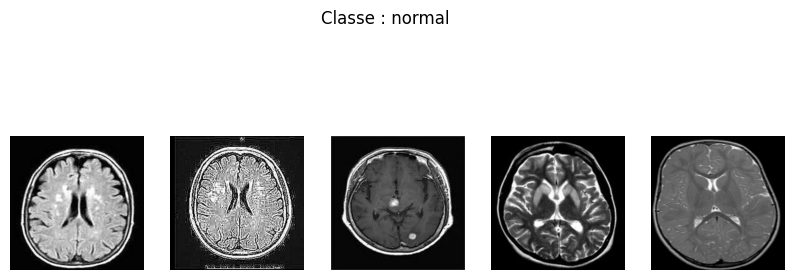

In [4]:
for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    plt.figure(figsize=(10, 4))
    
    for i in range(5):  
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"Classe : {cls}")
    plt.show()

Resize en taille standard pour ResNet : 224x224 (ResNet)

In [5]:
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224, 224))

print("Nouvelle taille :", img_resized.shape)

Nouvelle taille : (224, 224, 3)


definition de X et y à partir des images labelisées

In [6]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
img_size = 224

# Mapping : normal = 0, cancer = 1
CLASS_MAP = {"normal": 0, "cancer": 1}

X = []
y = []

classes = sorted(os.listdir(base_path))
print("Classes détectées :", classes)

for cls in classes:
    class_path = os.path.join(base_path, cls)

    if not os.path.isdir(class_path):
        continue

    label = CLASS_MAP.get(cls)
    if label is None:
        print(f"Classe inconnue ignorée : {cls}")
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        X.append(img)
        y.append(label)

Classes détectées : ['cancer', 'normal']


50 images "cancer" et 49 images "normal"

X, les images et y, les labels (0,1)

FN = prédit 0 (normal) alors que c'est 1 (cancer): cancer manqué (le plus critique)

FP = prédit 1 (cancer) alors que c'est 0 (normal): fausse alerte

normalisation en [0, 1] des pixels (de 0=noir à 255=blanc) pour stabiliser le modele

on évite l'explosion des gradients

In [7]:
X = np.array(X, dtype="float32") / 255.0   
y = np.array(y)
print(f"Distribution : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Dataset : {X.shape}, Labels : {y.shape}")

Distribution : {np.int64(0): np.int64(49), np.int64(1): np.int64(50)}
Dataset : (99, 224, 224, 3), Labels : (99,)


In [8]:
print("Mapping utilisé :", CLASS_MAP)
print("Labels uniques :", set(y))

Mapping utilisé : {'normal': 0, 'cancer': 1}
Labels uniques : {np.int64(0), np.int64(1)}


# analyse non supervisée

on va regarder si les images se partagent bien en 2 groupes (normal devrait etre séparé de cancer)

transformation des images en vecteur

In [9]:
X_features = X.reshape(X.shape[0], -1) # 1 image devient 1 ligne; 

print(X_features.shape)

(99, 150528)


Sans ResNet, on reste en pixels bruts: ARI négatifs et aucun clustering visible

raison: 150 000 pixels bruts pour seulement 99 images=>cluster sur pixels: trop de bruit

=>solution: utiliser ResNet50 pré-entraîné, SANS la tête de classification, sans la dernière couche

ResNet(50) donne une image en 2048 valeurs

=>=> cluster sur features

In [10]:
base_model = ResNet50(
    weights="imagenet",   # poids pré-entraînés sur ImageNet
    include_top=False,    # on retire la dernière couche Dense de classification (inutile=classe imags en 1000 categories)
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # on ne réentraîne pas ResNet, au contraire, on utilise tout ce qu'il a déjà appris

Extraction des features

In [11]:
feature_extractor = keras.Model(
    inputs=base_model.input,
    outputs=base_model.output # sortie avant la couche Dense pour les features
)

X_features_resnet = feature_extractor.predict(X)              
X_features_resnet = X_features_resnet.reshape(X.shape[0], -1) 
print("Features shape :", X_features_resnet.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 6s/step
Features shape : (99, 100352)


Standardisation des features avant réduction de dimension et clustering

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features_resnet)

Réduction de dimension avec PCA

In [13]:
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print(f"Composantes retenues : {pca.n_components_}")
print(f"Variance expliquée : {pca.explained_variance_ratio_.sum()*100:.1f}%")

(99, 50)
Composantes retenues : 50
Variance expliquée : 94.2%


Visualisation avec t-SNE en 2D

perplexity=30: on regarde les 30 voisins de chaque point

In [14]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42) # on fixe les positions aleatoires
X_tsne = tsne.fit_transform(X_pca)

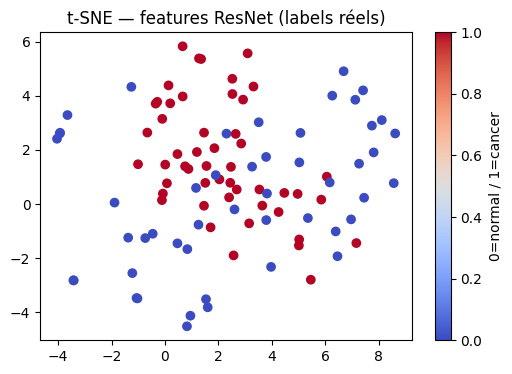

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="coolwarm")
plt.title("t-SNE — features ResNet (labels réels)")
plt.colorbar(label="0=normal / 1=cancer")
plt.show()

Clustering avec K-Means

distance euclidienne

baisser l'inertie (la somme des distances entre chaque point et son centre de cluster)

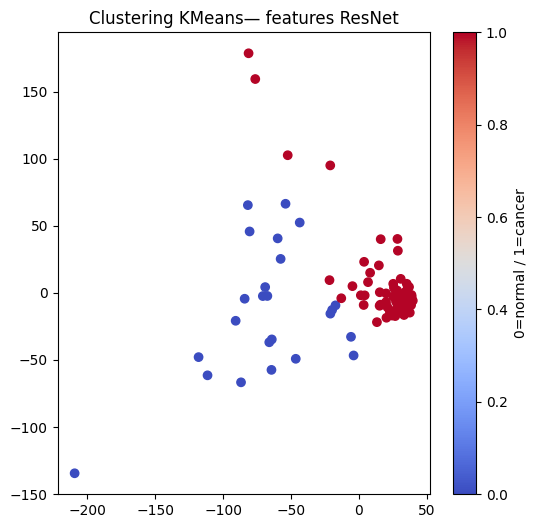

In [16]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_pca)
plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_kmeans, cmap="coolwarm")
plt.title("Clustering KMeans— features ResNet")
plt.colorbar(label="0=normal / 1=cancer")
plt.show()

Score ARI (Adjusted Rand Index)
comparaison clusters trouvés vs labels réels

ARI par K‑Means

In [17]:
ari_kmeans = adjusted_rand_score(y, clusters_kmeans)
print(f"ARI KMeans : {ari_kmeans:.4f}")

ARI KMeans : 0.1332


Clustering avec DBSCAN

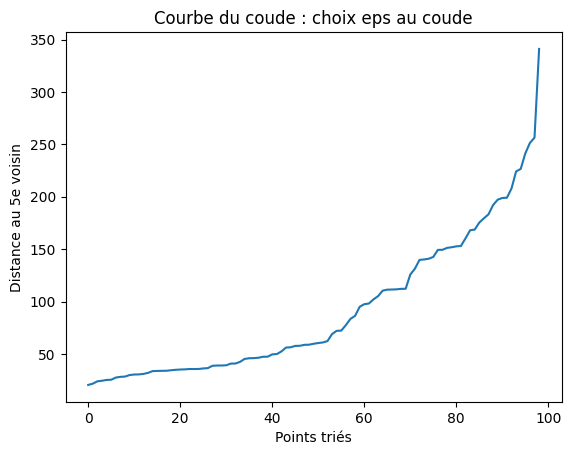

In [18]:
nn = NearestNeighbors(n_neighbors=5) # nb minimal de voisins dans un rayon epsilon
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.title("Courbe du coude : choix eps au coude")
plt.xlabel("Points triés")
plt.ylabel("Distance au 5e voisin")
plt.show()

In [19]:
dbscan = DBSCAN(eps=120, min_samples=3)  # on choisit epsilon selon le coude
clusters_db = dbscan.fit_predict(X_pca)

print("Clusters DBSCAN uniques :", np.unique(clusters_db))


Clusters DBSCAN uniques : [-1  0]


graphique de DBSSAN 

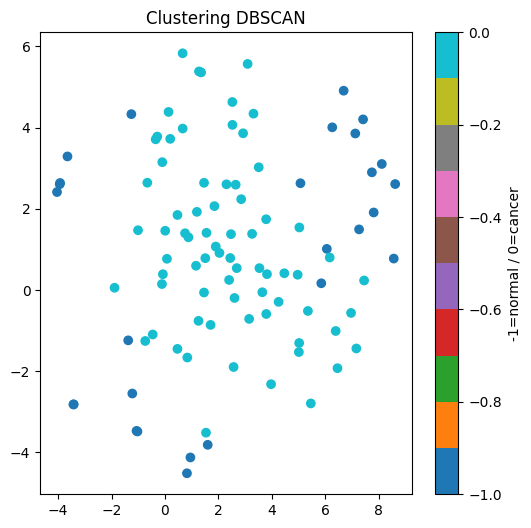

In [20]:
dbscan = DBSCAN(eps=120, min_samples=5)
clusters_db = dbscan.fit_predict(X_pca)

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_db, cmap="tab10")
plt.colorbar(label="-1=normal / 0=cancer")
plt.title("Clustering DBSCAN")

plt.show()

In [21]:
ari_dbscan = adjusted_rand_score(y, clusters_db)

print("ARI DBSCAN:", ari_dbscan)

ARI DBSCAN: 0.21904690656093365


=>on va tester AgglomerativeClustering pour comparer:

ARI Agglomératif : 0.2800


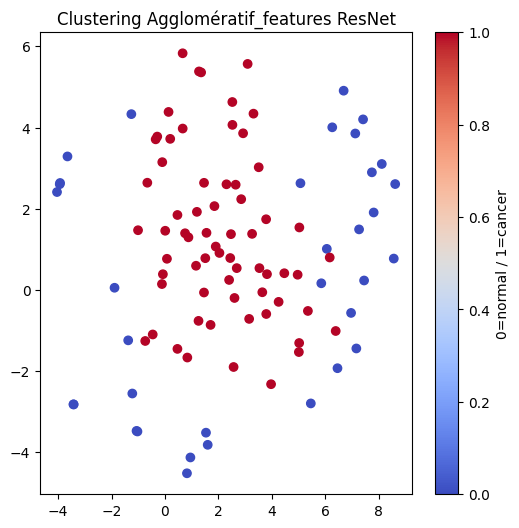

In [22]:
agglo = AgglomerativeClustering(n_clusters=2)
clusters_agglo = agglo.fit_predict(X_pca)

ari_agglo = adjusted_rand_score(y, clusters_agglo)
print(f"ARI Agglomératif : {ari_agglo:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_agglo, cmap="coolwarm")
plt.title("Clustering Agglomératif_features ResNet")
plt.colorbar(label="0=normal / 1=cancer")
plt.show()

=>on teste GMM, modèle plus nuancé avec probabilité d'appartenance de classes:

ARI GMM : 0.2188


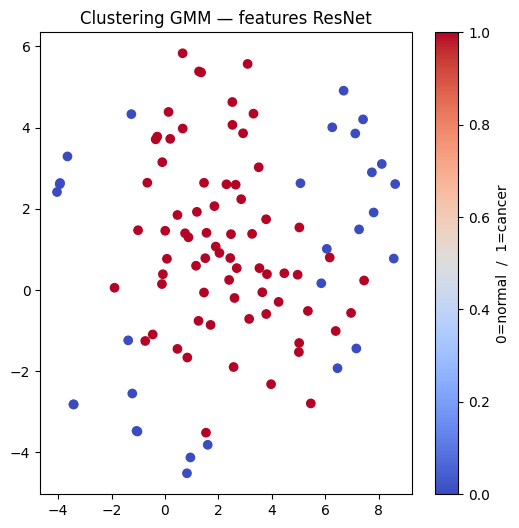

In [23]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type="diag",    # diagonale (1 valeur par dimension) pour simplifier car seulement 99 images
    reg_covar=1e-3, # régularisation, ajout d'une valeur sur la diagonale de la matrice (pour éviter matrices singulières)
    random_state=42
)

# en float64 plutôt que float32 (on passe de 7 à 15 chiffres significatifs) 
# avec Gauss, matrices de covariance nécessitent une grande précision numérique
X_pca_64 = X_pca.astype("float64") 

gmm.fit(X_pca_64) # étape 1 : apprentissage
clusters_gmm = gmm.predict(X_pca_64) # étape 2 : assignation des clusters.GMM utilise .predict()

ari_gmm = adjusted_rand_score(y, clusters_gmm)
print(f"ARI GMM : {ari_gmm:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_gmm, cmap="coolwarm")
plt.colorbar(label="0=normal  /  1=cancer")
plt.title("Clustering GMM — features ResNet")
plt.show()

GMM donne aussi les probabilités d'appartenance à chaque cluster

In [24]:
proba_gmm = gmm.predict_proba(X_pca)  # shape (99, 2)

# Probabilité que chaque image soit dans le cluster cancer
print("Probabilités (99 images):")
for i in range(99):
    print(f"  image {i} → cluster 0: {proba_gmm[i,0]:.2f} | cluster 1: {proba_gmm[i,1]:.2f}")

# Images ambiguës (GMM incertain)
ambigues = np.where((proba_gmm[:,0] > 0.4) & (proba_gmm[:,0] < 0.6))[0]
print(f"\nImages ambiguës (GMM incertain) : {len(ambigues)}")

Probabilités (99 images):
  image 0 → cluster 0: 0.00 | cluster 1: 1.00
  image 1 → cluster 0: 0.00 | cluster 1: 1.00
  image 2 → cluster 0: 0.00 | cluster 1: 1.00
  image 3 → cluster 0: 1.00 | cluster 1: 0.00
  image 4 → cluster 0: 0.00 | cluster 1: 1.00
  image 5 → cluster 0: 0.00 | cluster 1: 1.00
  image 6 → cluster 0: 0.00 | cluster 1: 1.00
  image 7 → cluster 0: 0.00 | cluster 1: 1.00
  image 8 → cluster 0: 0.00 | cluster 1: 1.00
  image 9 → cluster 0: 0.00 | cluster 1: 1.00
  image 10 → cluster 0: 0.00 | cluster 1: 1.00
  image 11 → cluster 0: 0.00 | cluster 1: 1.00
  image 12 → cluster 0: 0.00 | cluster 1: 1.00
  image 13 → cluster 0: 0.00 | cluster 1: 1.00
  image 14 → cluster 0: 0.00 | cluster 1: 1.00
  image 15 → cluster 0: 0.00 | cluster 1: 1.00
  image 16 → cluster 0: 0.00 | cluster 1: 1.00
  image 17 → cluster 0: 0.00 | cluster 1: 1.00
  image 18 → cluster 0: 0.00 | cluster 1: 1.00
  image 19 → cluster 0: 0.00 | cluster 1: 1.00
  image 20 → cluster 0: 0.00 | cluster 1: 1.

In [25]:
print("\n Comparaison clustering ")
print(f"ARI KMeans       : {ari_kmeans:.4f}")
print(f"ARI GMM          : {ari_gmm:.4f}")
print(f"ARI DBSCAN       : {ari_dbscan:.4f} ")
print(f"ARI Agglomératif : {ari_agglo:.4f}")



 Comparaison clustering 
ARI KMeans       : 0.1332
ARI GMM          : 0.2188
ARI DBSCAN       : 0.2190 
ARI Agglomératif : 0.2800


# analyse semi supervisee:

SPLIT TRAIN_TEST 

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

num_classes = len(classes)
print("Nombre de classes :", num_classes)

Train : (79, 224, 224, 3)
Test : (20, 224, 224, 3)
Nombre de classes : 2


# CNN 

metriques 2103 et 2003

In [ ]:
metrics_auc, metrics_acc, metrics_f1, metrics_loss = [], [], [] , []
 
 
def plot_metrics():
    """Trace l'évolution des AUC/Accuracy/F1 si des valeurs sont disponibles."""
    if len(metrics_auc) == 0:
        print("Aucune métrique enregistrée pour le moment.")
        return
    steps = range(1, len(metrics_auc) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, metrics_auc, label='AUC')
    plt.plot(steps, metrics_acc, label='Accuracy')
    plt.plot(steps, metrics_f1, label='F1 (macro)')
    plt.plot(steps, metrics_loss, label='loss')
    plt.xlabel('Étape / Itération')
    plt.ylabel('Score')
    plt.title("Évolution des métriques")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
 

au 2103

In [ ]:
def train_and_evaluate(model, X_train_data, y_train_data, X_test_data, y_test_data,
                       epochs=10, batch_size=32, datagen=None):
    """
    Entraîne et évalue un modèle Keras. Retourne (auc, acc, f1).
    Si des listes globales metrics_auc/metrics_acc/metrics_f1 existent, y ajoute les scores.
 
    Paramètres
    ----------
    model       : modèle Keras compilé
    X_train_data, y_train_data : données d'entraînement
    X_test_data,  y_test_data  : données de test
    epochs      : nombre d'epochs
    batch_size  : taille des batchs
    datagen     : ImageDataGenerator (data augmentation)
    """
 
    # --- Entraînement ---
    if datagen is not None:
        # avec augmentation - transfert learning
        model.fit(
            datagen.flow(X_train_data, y_train_data, batch_size=batch_size),
            epochs=epochs,
            validation_data=(X_test_data, y_test_data),
            verbose=1
        )
    else:
        # baseline CNN ou boucle SSL (sans augmentation)
        model.fit(
            X_train_data, y_train_data,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            verbose=1
        )
 
    # --- Évaluation Keras---
    loss, accuracy, roc_auc, precision, recall, fp, fn = model.evaluate(
        X_test_data, y_test_data, verbose=0
    )
    # F1 macro manuel pour Keras()
    y_proba = model.predict(X_test_data, verbose=0).flatten()
    y_pred  = (y_proba > 0.5).astype(int)
    f1      = sklearn_f1(y_test_data.astype(int), y_pred, average='macro')
 
    # Affichage
    print(f'AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, F1: {f1:.3f}')
    print(f"Loss              : {loss:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"Faux Positifs     : {int(fp)}")
    print(f"Faux Négatifs     : {int(fn)}")
 
    # Mise à jour des métriques globales
    try:
        metrics_auc.append(roc_auc)
        metrics_acc.append(accuracy)
        metrics_f1.append(f1)
        metrics_loss.append(loss)
    except NameError:
        pass
 
    return (roc_auc, accuracy, f1, loss)

2103

modele de base CNN

In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),
 
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
 
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
 
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
 
    layers.Dense(1, activation="sigmoid")
])
 
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)
 
y_train = y_train.astype("float32")
y_test  = y_test.astype("float32")
 
# --- Entraînement + évaluation du baseline via train_and_evaluate ---
print("Entraînement modèle de base_images labellisées")
baseline_metrics = train_and_evaluate(model, X_train, y_train, X_test, y_test,
                                      epochs=10, batch_size=32)
 
model_base = model

Entraînement du modèle de base sur les images labellisées...
Epoch 1/10


c:\Users\chris\traitement_images_semi_supervisées\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5493 - fn: 25.0000 - fp: 7.0000 - loss: 1.1746 - precision: 0.6500 - recall: 0.3421 - roc_auc: 0.6352 - val_accuracy: 0.2500 - val_fn: 0.0000e+00 - val_fp: 6.0000 - val_loss: 6.2046 - val_precision: 0.2500 - val_recall: 1.0000 - val_roc_auc: 0.3750
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 640ms/step - accuracy: 0.5352 - fn: 0.0000e+00 - fp: 33.0000 - loss: 2.1216 - precision: 0.5352 - recall: 1.0000 - roc_auc: 0.4382 - val_accuracy: 0.6250 - val_fn: 0.0000e+00 - val_fp: 3.0000 - val_loss: 0.6954 - val_precision: 0.4000 - val_recall: 1.0000 - val_roc_auc: 0.5000
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 606ms/step - accuracy: 0.5775 - fn: 24.0000 - fp: 6.0000 - loss: 0.6641 - precision: 0.7000 - recall: 0.3684 - roc_auc: 0.7301 - val_accuracy: 0.7500 - val_fn: 2.0000 - val_fp: 0.0000e+00 - val_loss: 0.6066 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.8333
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 608ms/step - accuracy: 0

matrice de confusion (baseline) 2103

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


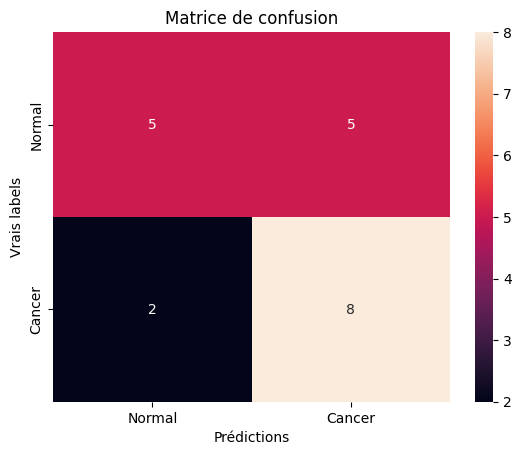

In [ ]:
y_proba_base = model_base.predict(X_test).flatten()
y_pred = (y_proba_base > 0.5).astype(int).flatten()
 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal", "Cancer"],
            yticklabels=["Normal", "Cancer"])
plt.title("Matrice de confusion baseline")
plt.xlabel("Prédictions")
plt.ylabel("Vrais labels")
plt.show()

courebe precision rappel 2103

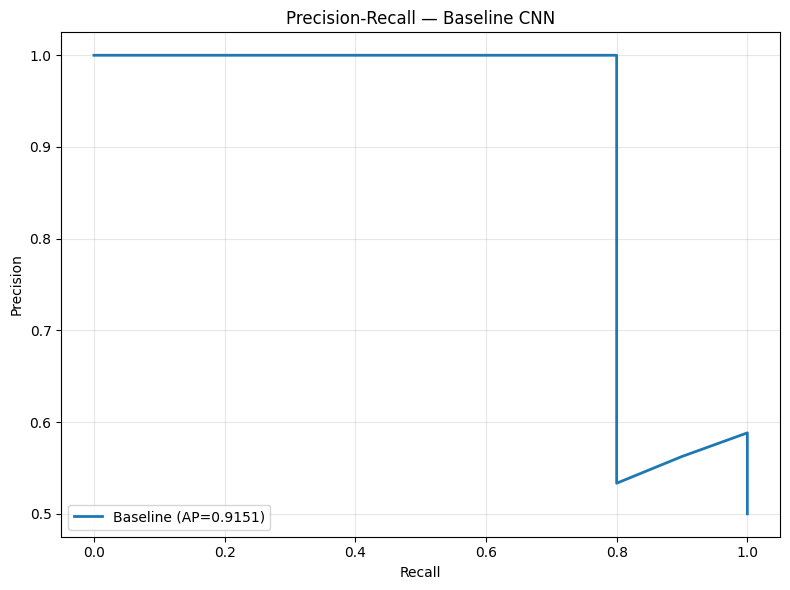

In [31]:
precision_base, recall_base, _ = precision_recall_curve(y_test, y_proba_base)
ap_base = average_precision_score(y_test, y_proba_base)
 
plt.figure(figsize=(8, 6))
plt.plot(recall_base, precision_base, label=f"Baseline (AP={ap_base:.4f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall — Baseline CNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

distribution des probabilités 2103

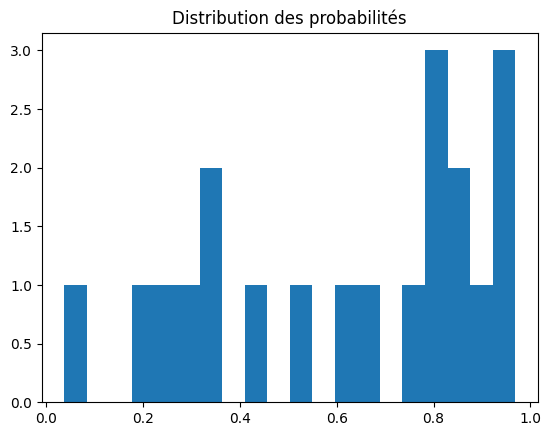

In [32]:
plt.hist(y_proba_base, bins=20)
plt.title("Distribution des probabilités")
plt.show()

data augmentation 2103

In [33]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

TRANSFERT LEARNING 2103

In [34]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # couches ResNet gelées
 
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
 
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)

print("Entraînement Transfer Learning (ResNet50 + augmentation)...")
tl_metrics = train_and_evaluate(model, X_train, y_train, X_test, y_test,
                                epochs=10, batch_size=8, datagen=datagen)

Entraînement Transfer Learning (ResNet50 + augmentation)...
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.4557 - fn: 17.0000 - fp: 26.0000 - loss: 0.8485 - precision: 0.4694 - recall: 0.5750 - roc_auc: 0.5163 - val_accuracy: 0.5000 - val_fn: 10.0000 - val_fp: 0.0000e+00 - val_loss: 0.6740 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.8350
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5443 - fn: 22.0000 - fp: 14.0000 - loss: 0.7809 - precision: 0.5625 - recall: 0.4500 - roc_auc: 0.5292 - val_accuracy: 0.7000 - val_fn: 0.0000e+00 - val_fp: 6.0000 - val_loss: 0.6144 - val_precision: 0.6250 - val_recall: 1.0000 - val_roc_auc: 0.8700
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7215 - fn: 4.0000 - fp: 18.0000 - loss: 0.6024 - precision: 0.6667 - recall: 0.9000 - roc_auc: 0.7558 - val_accuracy: 0.8500 - val_fn: 0.0000e+00 - val_fp: 3.0000 - val_loss: 0.5658 - val_precision: 0.7692 - val_recall: 1.0000 - val_roc_au

chargement des images sans label 2103

In [35]:
unlabeled_path = "data/mri_dataset_brain_cancer_oc/sans_label"
X_unlabeled = []
 
for img_name in os.listdir(unlabeled_path):
    img_path = os.path.join(unlabeled_path, img_name)
    img = cv2.imread(img_path)
 
    if img is None:
        continue
 
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    X_unlabeled.append(img)
 
X_unlabeled = np.array(X_unlabeled, dtype="float32") / 255.0
print("Unlabeled shape:", X_unlabeled.shape)

Unlabeled shape: (1311, 224, 224, 3)


generation des pseudo labels 2103

In [ ]:
def get_pseudo_labels(model, X_unlabeled_current, unlabeled_indices, threshold=0.95):
    """
    Génère des pseudo-labels pour les images où le modèle est confiant.
    Retourne les indices globaux retenus et leurs pseudo-labels.
    """
    pseudo_probs = model.predict(X_unlabeled_current, verbose=0).flatten()

    confident_mask         = (pseudo_probs > threshold) | (pseudo_probs < (1 - threshold))
    selected_indices_local = np.where(confident_mask)[0]

    selected_global_indices = [unlabeled_indices[i] for i in selected_indices_local]
    pseudo_labels           = (pseudo_probs[selected_indices_local] > 0.5).astype("float32").tolist()

    print(f"Nombre d'images confiantes (> {threshold:.2f}) : {len(selected_global_indices)}")
    return selected_global_indices, pseudo_labels

pesudo labels initiaux pour construire X_combined 2103

In [ ]:
THRESHOLD = 0.9
pseudo_probs = model.predict(X_unlabeled, verbose=0).flatten()

mask     = (pseudo_probs > THRESHOLD) | (pseudo_probs < (1 - THRESHOLD))
X_pseudo = X_unlabeled[mask]
y_pseudo = (pseudo_probs[mask] > 0.5).astype("float32")

print(f"Pseudo labels confiants détectés par le Transfer Learning : {len(y_pseudo)}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 169s 4s/step
Pseudo labels retenus : 41


re initialisation du modele avant la boucle 2103

In [38]:
ssl_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
ssl_base.trainable = False
 
ssl_model = keras.Sequential([
    ssl_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
 
ssl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)
 
print("Modèle ssl_model réinitialisé pour la boucle semi-supervisée.")

Modèle ssl_model réinitialisé pour la boucle semi-supervisée.


DATASET GLOBAL

In [ ]:
X_full = np.concatenate([X_train, X_unlabeled])
y_full = np.concatenate([y_train, np.full(len(X_unlabeled), -1)])  # -1 = unlabeled

current_labeled_indices = list(range(len(X_train)))
unlabeled_indices       = list(range(len(X_train), len(X_full)))

BOUCLE SEMI-SUPERVISÉE 2103

In [ ]:
def semi_supervised_training(
    model,
    X_full,
    y_full,
    current_labeled_indices,
    unlabeled_indices,
    X_test,
    y_test,
    confidence_threshold=0.95,
    iterations=5,
    batch_size=8,
    epochs=5
):
    for iteration in range(iterations):
        print(f"\n--- Itération {iteration+1} ---")

        # 1. Dataset courant ← équivalent Subset + DataLoader PyTorch
        X_labeled = X_full[current_labeled_indices]
        y_labeled = y_full[current_labeled_indices]

        print(f"Entraînement sur {len(X_labeled)} images...")
        pseudo_label_auc, pseudo_label_acc, pseudo_label_f1 = train_and_evaluate(
            model, X_labeled, y_labeled, X_test, y_test,
            epochs=epochs, batch_size=batch_size
        )

        # 2. Génération pseudo-labels ← équivalent get_pseudo_labels() PyTorch
        print("Génération de pseudo-labels...")

        if len(unlabeled_indices) == 0:
            print("Plus d'images non labellisées, on arrête là !")
            break

        X_unlabeled_current = X_full[unlabeled_indices]
        pseudo_indices, pseudo_labels = get_pseudo_labels(
            model, X_unlabeled_current, unlabeled_indices,
            threshold=confidence_threshold
        )
        print(f"{len(pseudo_indices)} nouveaux pseudo-labels ajoutés.")

        if len(pseudo_indices) == 0:
            print("Plus de pseudo-labels trouvés, on arrête là !")
            break

        # 3. Mise à jour in-place ← équivalent temp_dataset.labels[idx] PyTorch
        new_indices = []
        for idx, label in zip(pseudo_indices, pseudo_labels):
            if idx not in current_labeled_indices:  # ne pas écraser les vrais labels
                y_full[idx] = label
                current_labeled_indices.append(idx)
                new_indices.append(idx)

        # 4. Mise à jour unlabeled_indices
        new_indices_set   = set(new_indices)
        unlabeled_indices = [i for i in unlabeled_indices if i not in new_indices_set]

        print(f"Dataset train actuel    : {len(current_labeled_indices)}")
        print(f"Restant non labellisé   : {len(unlabeled_indices)}")

    return model, current_labeled_indices, y_full

Lancement de la boucle 2103

In [ ]:
model_final, current_labeled_indices, y_full = semi_supervised_training(
    model=ssl_model,
    X_full=X_full,
    y_full=y_full,
    current_labeled_indices=current_labeled_indices,
    unlabeled_indices=unlabeled_indices,
    X_test=X_test,
    y_test=y_test,
    confidence_threshold=0.95,
    iterations=10,
    epochs=5
)


===== Iteration 1 =====
Entraînement sur 120 images...
Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 780ms/step - accuracy: 0.5278 - fn: 25.0000 - fp: 26.0000 - loss: 0.7591 - precision: 0.3659 - recall: 0.3750 - roc_auc: 0.5092 - val_accuracy: 1.0000 - val_fn: 0.0000e+00 - val_fp: 0.0000e+00 - val_loss: 0.3566 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.0000e+00
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6574 - fn: 26.0000 - fp: 11.0000 - loss: 0.5706 - precision: 0.5600 - recall: 0.3500 - roc_auc: 0.7469 - val_accuracy: 1.0000 - val_fn: 0.0000e+00 - val_fp: 0.0000e+00 - val_loss: 0.1428 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.0000e+00
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 644ms/step - accuracy: 0.7778 - fn: 10.0000 - fp: 14.0000 - loss: 0.4767 - precision: 0.6818 - recall: 0.7500 - roc_auc: 0.8629 - val_accuracy: 1.0000 - val_fn: 0.0000e+00 - val_fp: 0.0000e+00 - val_loss: 0.1187 - val_precision: 0.0000e+00 - v

Metriques finaux 2103

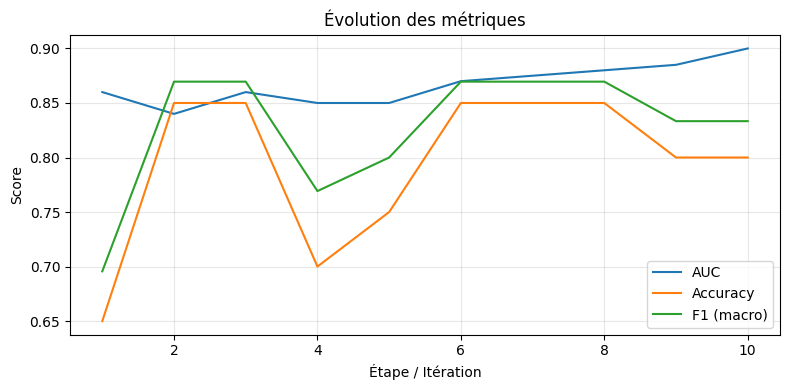

In [41]:
plot_metrics()

modele de base

model = keras.Sequential([
 
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),  # 32 filtres
    layers.MaxPooling2D(2, 2),                                                 # réduction 2×2
 
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
 
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
 
    layers.Flatten(),                       # on aplatit le 2D en 1D
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),                    # désactivation de 50 % des neurones contre l'overfit
 
    layers.Dense(1, activation="sigmoid")   # proba d'image cancer (dernière couche)
])
 
# loss function en classification binaire
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)
 
# y_train et y_test
y_train = y_train.astype("float32")
y_test  = y_test.astype("float32")

entrainement du modele de base

print("Entraînement du modèle de base sur les images labellisées...")
 
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
 
model_base = model

evaluation du modele de base

loss, accuracy, roc_auc, precision, recall, fp, fn = model.evaluate(X_test, y_test, verbose=0)
 
f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
 
print(f'AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, F1: {f1:.3f}')
print(f"Loss Baseline     : {loss:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"Faux Positifs     : {int(fp)}")
print(f"Faux Négatifs     : {int(fn)}")
 
try:
    metrics_auc.append(roc_auc)
    metrics_acc.append(accuracy)
    metrics_f1.append(f1)
except NameError:
    pass
 
# Matrice de confusion
y_proba_base = model_base.predict(X_test).flatten()   # proba prédite d'une image cancer
y_pred = (y_proba_base > 0.5).astype(int).flatten()   # correspondance probas → classe 0 ou 1
 
cm = confusion_matrix(y_test, y_pred)
 
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal", "Cancer"],
            yticklabels=["Normal", "Cancer"])
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Vrais labels")
plt.show()
 
# Courbe précision-rappel
precision_base, recall_base, _ = precision_recall_curve(y_test, y_proba_base)
ap_base = average_precision_score(y_test, y_proba_base)
 
plt.figure(figsize=(8, 6))
plt.plot(recall_base, precision_base, label=f"Baseline (AP={ap_base:.4f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall — Baseline CNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
# Distribution des probabilités (pour choisir le threshold)
plt.hist(y_proba_base, bins=20)
plt.title("Distribution des probabilités")
plt.show()
 

data augmentation

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
 
datagen.fit(X_train)

Transfer Learning avec ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
 
base_model.trainable = False  # ResNet déjà pré-entraîné ; seules les couches ajoutées seront entraînées
 
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
 
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)
 
# Entraînement avec augmentation
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    epochs=10,
    validation_data=(X_test, y_test)
)

chargement des labels sans image

unlabeled_path = "data/mri_dataset_brain_cancer_oc/sans_label"
 
X_unlabeled = []
 
for img_name in os.listdir(unlabeled_path):
    img_path = os.path.join(unlabeled_path, img_name)
    img = cv2.imread(img_path)
 
    if img is None:
        continue
 
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    X_unlabeled.append(img)
 
X_unlabeled = np.array(X_unlabeled, dtype="float32") / 255.0
 
print("Unlabeled shape:", X_unlabeled.shape)

Génération des pseudo-labels

def get_pseudo_labels(model, X_unlabeled, threshold=0.95):
    """
    Génère des pseudo-labels pour les images où le modèle est confiant.
    Retourne les indices des images retenues et leurs pseudo-labels.
    """
    # Prédictions : probabilité d'appartenir à la classe 1 (cancer)
    pseudo_probs = model.predict(X_unlabeled).flatten()
 
    # On garde les prédictions très confiantes (proche de 0 ou de 1)
    confident_mask = (pseudo_probs > threshold) | (pseudo_probs < (1 - threshold))
 
    pseudo_labeled_indices = np.where(confident_mask)[0].tolist()
    pseudo_labels          = (pseudo_probs[confident_mask] > 0.5).astype("float32").tolist()
 
    print(f"Nombre d'images pour lesquelles le modèle est confiant (> {threshold:.2f}) : {len(pseudo_labeled_indices)}")
    return pseudo_labeled_indices, pseudo_labels
 

Pseudo-labels initiaux (avant la boucle)

THRESHOLD = 0.9
pseudo_probs = model.predict(X_unlabeled).flatten()
 
mask     = (pseudo_probs > THRESHOLD) | (pseudo_probs < (1 - THRESHOLD))
X_pseudo = X_unlabeled[mask]
y_pseudo = (pseudo_probs[mask] > 0.5).astype("float32")
 
print(f"Pseudo labels retenus : {len(y_pseudo)}")
 
# Concaténation vrais labels + pseudo-labels
X_combined = np.concatenate([X_train, X_pseudo])
y_combined = np.concatenate([y_train, y_pseudo])

Boucle de semi-supervision

def semi_supervised_training(
    model,
    X_train,
    y_train,
    X_unlabeled,
    X_test,
    y_test,
    confidence_threshold=0.95,
    iterations=5,
    batch_size=8,
    epochs=5
):
    X_labeled = X_train.copy()
    y_labeled = y_train.copy()
 
    for i in range(iterations):
        print(f"\n===== Iteration {i+1} =====")
 
        # 1. Prédictions sur données non labellisées
        pseudo_labeled_indices, pseudo_labels_list = get_pseudo_labels(
            model, X_unlabeled, threshold=confidence_threshold
        )
 
        X_pseudo_iter = X_unlabeled[pseudo_labeled_indices]
        y_pseudo_iter = np.array(pseudo_labels_list, dtype="float32")
 
        print(f"Pseudo labels retenus : {len(y_pseudo_iter)}")
 
        if len(y_pseudo_iter) == 0:
            print("Aucun pseudo label fiable, arrêt.")
            break
 
        # 2. Ajout au dataset
        X_labeled = np.concatenate([X_labeled, X_pseudo_iter])
        y_labeled = np.concatenate([y_labeled, y_pseudo_iter])
 
        # 3. Retirer ces images du pool non labellisé
        keep_mask  = np.ones(len(X_unlabeled), dtype=bool)
        keep_mask[pseudo_labeled_indices] = False
        X_unlabeled = X_unlabeled[keep_mask]
 
        print(f"Dataset train actuel : {X_labeled.shape}")
        print(f"Entraînement sur {X_labeled.shape[0]} images...")
 
        # 4. Ré-entraînement
        model.fit(
            X_labeled,
            y_labeled,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )
 
        # 5. Évaluations successives
        loss, acc, roc_auc, precision, recall, fp, fn = model.evaluate(X_test, y_test, verbose=0)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
 
        print(f"Accuracy       : {acc:.4f}")
        print(f"Loss           : {loss:.4f}")
        print(f"ROC AUC        : {roc_auc:.4f}")
        print(f"Precision      : {precision:.4f}")
        print(f"Recall         : {recall:.4f}")
        print(f"F1 Score       : {f1:.4f}")
        print(f"Faux Positifs  : {int(fp)}")
        print(f"Faux Négatifs  : {int(fn)}")
        print(f"Pseudo labels ajoutés : {len(y_pseudo_iter)}")
 
        # Mise à jour des métriques globales
        try:
            metrics_auc.append(roc_auc)
            metrics_acc.append(acc)
            metrics_f1.append(f1)
        except NameError:
            pass
 
        if len(X_unlabeled) == 0:
            print("Plus d'images non labellisées, on arrête !")
            break
 
    return model, X_labeled, y_labeled

Lancement de la boucle semi-supervisée

model, X_train_final, y_train_final = semi_supervised_training(
    model=model,
    X_train=X_combined,
    y_train=y_combined,
    X_unlabeled=X_unlabeled,
    X_test=X_test,
    y_test=y_test,
    confidence_threshold=0.95,
    iterations=10,
    epochs=5
)
 
model_final = model
 
# Visualisation finale des métriques
plot_metrics()

# ANCIENNE VERSION
model = keras.Sequential([

    layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)), # 32 filtres
    layers.MaxPooling2D(2,2), # reduction en 2x2

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(), # on aplatit le 2D en 1D
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5), # desactivation de 50% de neurones contre l'overfit

    layers.Dense(1,activation="sigmoid") # proba d'image cancer (dernière couche)
])


on cherche à minimiser les mauvaises predictions=> loss function
modele de classification=> en binary_crossentropy

# ANCIEN MODELE
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)

# ANCIEN MODELE
model.summary()

flatten a généré un vecteur de 86528 valeurs (provenant de 26x26x128 de la derniere couche)

# ANCIEN MODELE
y_train = y_train.astype("float32") 
y_test  = y_test.astype("float32")

# ANCIEN MODELE
print(y_train.shape)
print(np.unique(y_train))

entraînement

# ANCIEN MODELE
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

model_base = model

metriques

particularité du calcul du f1_sccore non supporté par toutes les versions de Keras:
calcul manuel entre precision et recall

# ANCIEN MODELE
loss, accuracy, roc_auc, precision, recall, fp, fn = model.evaluate(X_test, y_test, verbose=0)

f1 = 2 * (precision * recall) / (precision + recall + 1e-7)  # 1e-7 pour éviter division par zéro

print(f"Baseline accuracy : {accuracy*100:.2f}%")
print(f"Loss              : {loss:.4f}")
print(f"ROC AUC           : {roc_auc:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"Faux Positifs     : {int(fp)}")
print(f"Faux Négatifs     : {int(fn)}")

matrice de confusion sur le test set (20 échantillons)

# ANCIEN MODELE
y_proba_base = model_base.predict(X_test).flatten() # proba prédite d'une image cancer
y_pred_base = (y_proba_base > 0.5).astype(int).flatten() # correspondance probas avec la classe prédite 0 ou 1

cm_base = confusion_matrix(y_test, y_pred_base)

sns.heatmap(cm_base, annot=True, fmt="d",
            xticklabels=["Normal","Cancer"],
            yticklabels=["Normal","Cancer"])
plt.title("Matrice de confusion baseline")
plt.xlabel("Prédictions")
plt.ylabel("Vrais labels")

Courbe ROC-AUC

# ANCIEN MODELE
fpr, tpr, _ = roc_curve(y_test, y_proba_base)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.text(
    0.6, 0.2, 
    f"AUC = {roc_auc:.4f}", 
    fontsize=12, 
    bbox=dict(facecolor="white", alpha=0.7)
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Baseline")
print(f"ROC AUC : {roc_auc:.4f}")

# ANCIEN MODELE
precision_base,  recall_base,  _ = precision_recall_curve(y_test, y_proba_base)

ap_base  = average_precision_score(y_test, y_proba_base)

plt.figure(figsize=(8, 6))
plt.plot(recall_base,  precision_base,  label=f"Baseline     (AP={ap_base:.4f})",  linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall — Baseline CNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AP Baseline CNN      : {ap_base:.4f}")


data augmentation car seulement 99 echantillons avac labels (éviter overfit)

# ANCIEN MODELE
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

transfer learning avec ResNet50, modèle pré-entraîné.

# ANCIEN MODELE
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # ResNet déjà multi-entraîné; seules les couches ajoutées (Dense, Dropout) seront entraînées

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")  
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")]
)

model.summary()

data augmentation et entrainement de ResNet sur les données IRM

# ANCIEN MODELE
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    epochs=10,
    validation_data=(X_test, y_test)
)

Distribution des probabilités pour visualiser le threshold

combien d’images reçoivent chaque probabilité

# ANCIEN MODELE
plt.hist(y_proba_base, bins=20)
plt.title("Distribution des probabilités")

proba entre O.15 et 0.55: modèle incertain
proba entre [0.55 et 0.9[ Le modèle pense qu'il s'agit probablement de cancers

proba entre 0 et 0.1: modèle très confiant que ces images sont normales (classe 0)
proba: à partir de 0.9: modele très confiant que ces images sont des cancers (classe 1)
donc les images avec proba <0.1 et >0.9 peuvent être pseudo-labellisées

predictions sur images sans label

# ANCIEN MODELE
unlabeled_path = "data/mri_dataset_brain_cancer_oc/sans_label"

X_unlabeled = []

for img_name in os.listdir(unlabeled_path):
    img_path = os.path.join(unlabeled_path, img_name)
    img = cv2.imread(img_path)
    
    if img is None:
        continue
    
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    X_unlabeled.append(img)

X_unlabeled = np.array(X_unlabeled, dtype="float32") / 255.0

print("Unlabeled shape:", X_unlabeled.shape)

modele semi supervise

le modele renvoie une probabilité entre 0 et 1 pour chaque image non labelisée

# ANCIEN MODELE
THRESHOLD = 0.9
pseudo_probs = model.predict(X_unlabeled).flatten()

on garde les prédictions très confiantes:
-predictions >0.9 (classe 1)
-predictions <0.1 (classe 0)
-les autres ne sont pas conservées

# ANCIEN MODELE
mask = (pseudo_probs > THRESHOLD) | (pseudo_probs < (1 - THRESHOLD))

X_pseudo = X_unlabeled[mask] # images retenues dont le modèle est très confiant

Création des pseudo‑labels

# ANCIEN MODELE
y_pseudo = (pseudo_probs[mask] > 0.5).astype("float32")

print(f"Pseudo labels retenus : {len(y_pseudo)}")
print(f"Distribution : {np.unique(y_pseudo, return_counts=True)}")

# ANCIEN MODELE
print("y_train shape:", y_train.shape) # vrais labels
print("y_pseudo shape:", y_pseudo.shape) # labels predits

concaténation des pseudo-labels avec les vrais labels

# ANCIEN MODELE
X_combined = np.concatenate([X_train, X_pseudo])
y_combined = np.concatenate([y_train, y_pseudo])

print(X_combined.shape)
print(y_combined.shape)

entrainement successif

# ANCIEN MODELE
def semi_supervised_training(
    model,
    X_train,
    y_train,
    X_unlabeled,
    X_test,
    y_test,
    confidence_threshold=0.95,
    iterations=5,
    batch_size=8,
    epochs=5
):

    X_labeled = X_train.copy()
    y_labeled = y_train.copy()

    for i in range(iterations):

        print(f"\n===== Iteration {i+1} =====")

        # prédictions sur données non labelisées
        preds = model.predict(X_unlabeled)

        # sélection forte confiance
        high_conf_mask = (preds > confidence_threshold) | (preds < (1 - confidence_threshold))

        X_pseudo = X_unlabeled[high_conf_mask.flatten()]
        y_pseudo = (preds[high_conf_mask] > 0.5).astype(int).flatten()

        print(f"Pseudo labels retenus : {len(y_pseudo)}")

        if len(y_pseudo) == 0:
            print("Aucun pseudo label fiable, arrêt.")
            break

        # ajout au dataset
        X_labeled = np.concatenate([X_labeled, X_pseudo])
        y_labeled = np.concatenate([y_labeled, y_pseudo])

        # retirer ces images du pool non labelisé
        X_unlabeled = X_unlabeled[~high_conf_mask.flatten()]

        print(f"Dataset train actuel : {X_labeled.shape}")

        # réentrainement
        model.fit(
            X_labeled,
            y_labeled,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

        # évaluations succesives
        loss, acc, roc_auc, precision, recall, fp, fn = model.evaluate(X_test, y_test, verbose=0)

        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)

        print(f"Accuracy  : {acc:.4f}")
        print(f"Loss      : {loss:.4f}")
        print(f"ROC AUC   : {roc_auc:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1 Score  : {f1:.4f}")
        print(f"Faux Positifs : {int(fp)}")
        print(f"Faux Négatifs : {int(fn)}")
        print(f"Entraînement sur {X_labeled.shape[0]} images...")
        print(f"Pseudo labels ajoutés : {len(y_pseudo)}")
                
    return model, X_labeled, y_labeled 

modele entrainé et élargi (label et pseudo-label) sur X_combined

y_combined considéré comme y_train de départ

lancement de la fonction:

# ANCIEN MODELE
model, X_train_final, y_train_final = semi_supervised_training(
    model=model,                        
    X_train=X_combined,                 
    y_train=y_combined,                 
    X_unlabeled=X_unlabeled,    
    X_test=X_test,
    y_test=y_test,
    confidence_threshold=0.95,
    iterations=10,
    epochs=5
)

model_final = model

Graphe de la fonction de perte

# ANCIEN MODELE
iterations = [0, 1, 2]
loss_values = [0.4698, 0.4464, 0.4499, 0.4300, 0.4096, 0.4188, 0.4128, 0.4131, 0.3936, 0.4320]
labels_iter = ["avant\npseudo-labels", "iter 1", "iter 2","iter 3", "iter 4","iter 5", "iter 6", "iter 7", "iter 8", "iter 9"]

iterations = list(range(len(loss_values)))  # ← automatique, plus d'erreur possible
print(f"iterations  : {len(iterations)} valeurs")
print(f"loss_values : {len(loss_values)} valeurs")

labels_iter = ["avant\npseudo-labels"] + [f"iter {i}" for i in range(1, len(loss_values))]

plt.figure(figsize=(8, 5))
plt.plot(iterations, loss_values, marker="o", color="steelblue", linewidth=2, markersize=8)

for i, (x, y_val) in enumerate(zip(iterations, loss_values)):
    plt.annotate(f"{y_val:.4f}", xy=(x, y_val),
                 xytext=(0, 12), textcoords="offset points",
                 ha="center", fontsize=9)

plt.axvline(x=iterations[loss_values.index(min(loss_values))],
            color="red", linestyle="--", alpha=0.5,
            label=f"Meilleure loss ({min(loss_values):.4f})")

plt.xticks(iterations, labels_iter)
plt.xlabel("Itération semi-supervisée")
plt.ylabel("Loss (test set)")
plt.title("Évolution de la loss — Entraînement semi-supervisé")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

COURBE PRECISION-RECALL

precision_recall_curve attend shape (N,) 

model.predict() retourne shape (N, 1) avec sigmoid => utilisation de flatten

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


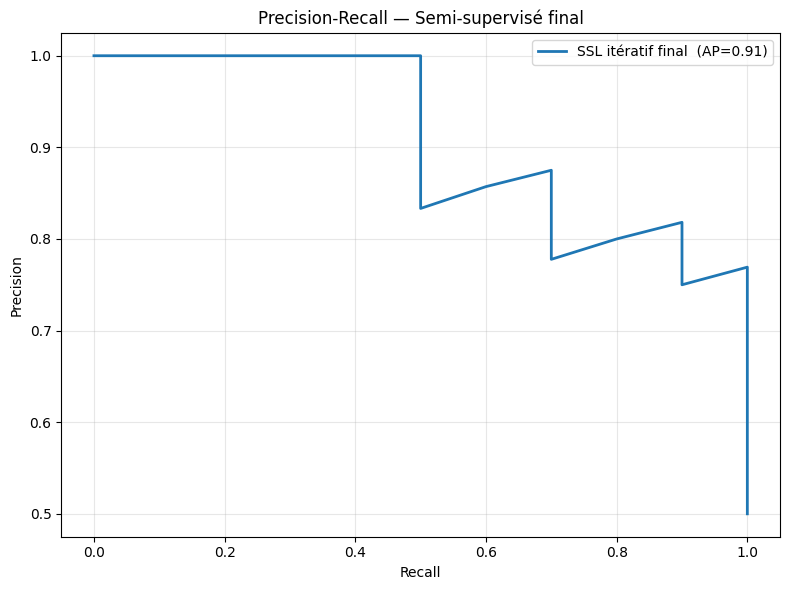

AP SSL itératif      : 0.9120


In [42]:

y_proba_final = model_final.predict(X_test).flatten() # après itérations SSL

precision_final, recall_final, _ = precision_recall_curve(y_test, y_proba_final)

ap_final = average_precision_score(y_test, y_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(recall_final, precision_final, label=f"SSL itératif final  (AP={ap_final:.2f})", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall — Semi-supervisé final")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AP SSL itératif      : {ap_final:.4f}")

Matrice de confusion sur data train augmenté (vrais labels+ pseudo-labels)

8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step


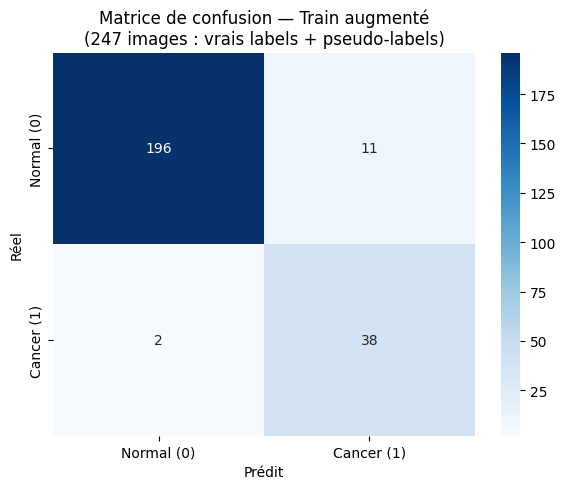

Vrais Négatifs  (TN) : 196  normaux bien détectés
Faux Positifs   (FP) : 11  normaux classés cancer
Faux Négatifs   (FN) : 2  cancers manqués
Vrais Positifs  (TP) : 38  cancers bien détectés


In [ ]:
# On garde uniquement les indices qui ont un label valide (vrais + pseudo-labels)
# y_full contient -1 pour les images encore unlabeled → à exclure
labeled_mask = y_full != -1

X_train_final = X_full[labeled_mask]
y_train_final = y_full[labeled_mask]

# Prédictions sur le dataset final enrichi
y_proba_train = model_final.predict(X_train_final).flatten()
y_pred_train  = (y_proba_train > 0.5).astype(int)

cm_train = confusion_matrix(y_train_final, y_pred_train)

tn, fp, fn, tp = cm_train.ravel()

plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=["Normal (0)", "Cancer (1)"],
            yticklabels=["Normal (0)", "Cancer (1)"])
plt.title(f"Matrice de confusion — Train augmenté\n({len(y_train_final)} images : vrais labels + pseudo-labels)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

print(f"Vrais Négatifs  (TN) : {tn}  normaux bien détectés")
print(f"Faux Positifs   (FP) : {fp}  normaux classés cancer")
print(f"Faux Négatifs   (FN) : {fn}  cancers manqués")
print(f"Vrais Positifs  (TP) : {tp}  cancers bien détectés")

=>Le modèle apprend bien: seulement 3 cancers manqués et 10 FP; tout le reste est bien prédit.

Matrice de confusion finale sur test (vrais labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


Text(50.722222222222214, 0.5, 'Vrais labels')

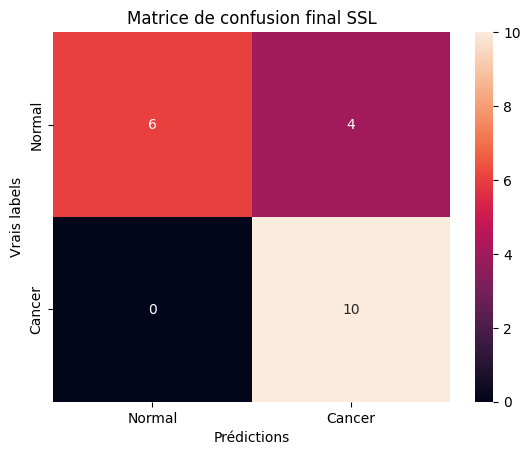

In [44]:

y_proba_final = model_final.predict(X_test).flatten()
y_pred_final  = (y_proba_final > 0.5).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm_final, annot=True, fmt="d",
            xticklabels=["Normal","Cancer"],
            yticklabels=["Normal","Cancer"])
plt.title("Matrice de confusion final SSL")
plt.xlabel("Prédictions")
plt.ylabel("Vrais labels")

In [45]:

tn, fp, fn, tp = cm_final.ravel()
print(f"Vrais Négatifs  (TN) : {tn}  normaux bien détectés")
print(f"Faux Positifs   (FP) : {fp}  normaux classés cancer")
print(f"Faux Négatifs   (FN) : {fn}  cancers manqués ")
print(f"Vrais Positifs  (TP) : {tp}  cancers bien détectés")

Vrais Négatifs  (TN) : 6  normaux bien détectés
Faux Positifs   (FP) : 4  normaux classés cancer
Faux Négatifs   (FN) : 0  cancers manqués 
Vrais Positifs  (TP) : 10  cancers bien détectés


=>grâce au SSL sur 1400 images non labelisées, le modèle est passé de 4 cancers manqués à 0 sur le test set indépendant.
le modèle généralise bien

# ANCIEN MODELE
print("\n", classification_report(
    y_test, y_pred_final,
    target_names=["Normal", "Cancer"]
))